In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [6]:
df = pd.read_csv('/content/sample_data/clusteringmidterm (1).csv')

In [7]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [9]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [10]:
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [11]:
df = df.drop('CUST_ID', axis=1)

In [12]:
df.fillna(df.mean(), inplace=True)

In [36]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

In [68]:
df_clean = df[~((df < (Q1 - 1.5 * IQR)) |
(df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [69]:
print(df.shape)
print(df_clean.shape)

(8950, 18)
(3008, 18)


In [70]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

In [71]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

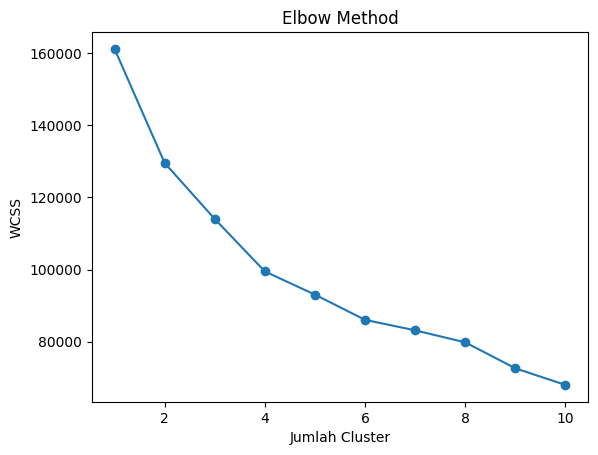

In [72]:
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster')
plt.ylabel('WCSS')
plt.show()

In [75]:
kmeans = KMeans(n_clusters=4, random_state=42)

clusters = kmeans.fit_predict(scaled_data)

df['Cluster'] = clusters

In [76]:
score = silhouette_score(scaled_data, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.24858304915149282


In [77]:
df_clean.groupby('Cluster').mean()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,3457.758758,1.000000,341.475000,216.990000,124.485000,2302.882553,0.468750,0.125000,0.302083,0.458334,8.375000,7.250000,7500.000000,1295.226328,1010.891526,0.000000,12.0
1,1333.023928,0.979095,226.227753,169.351291,57.211397,518.787776,0.177988,0.095095,0.082773,0.125860,2.201152,3.167067,3105.400864,803.355291,495.312895,0.018542,12.0
3,914.237425,0.979082,718.776532,269.462988,449.374122,170.524435,0.878317,0.160851,0.798982,0.042621,0.756816,17.836423,3351.234262,843.912744,447.753163,0.050572,12.0


In [78]:
from sklearn.decomposition import PCA

In [79]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

In [80]:
pca_df = pd.DataFrame(data=pca_data, columns=['PCA1', 'PCA2'])

pca_df['Cluster'] = clusters

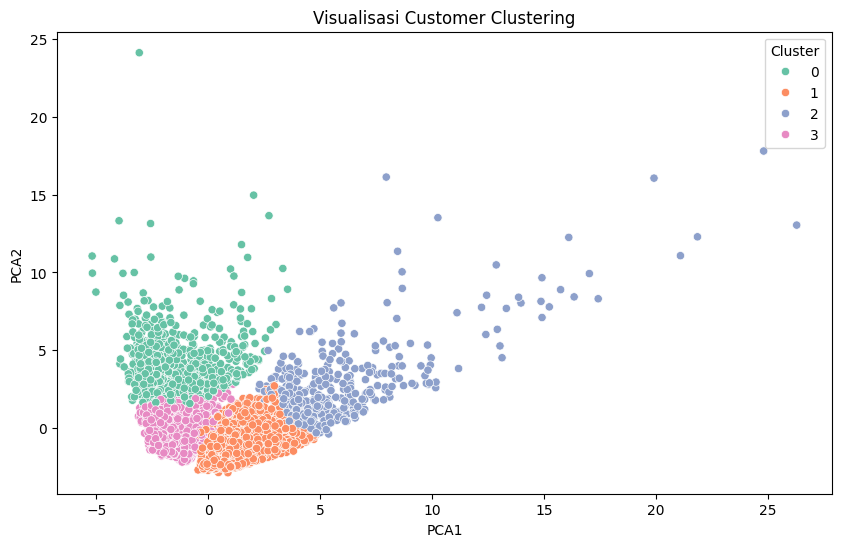

In [81]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    data=pca_df,
    palette='Set2'
)

plt.title('Visualisasi Customer Clustering')
plt.show()

In [82]:
df.groupby('Cluster').mean()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,4822.699998,0.968403,537.686638,338.061843,199.721901,4847.014267,0.301482,0.145874,0.196653,0.501060,15.217765,8.294174,7873.691065,3766.175241,2082.425440,0.036863,11.425024
1,818.566788,0.909251,1198.014036,566.649962,631.614086,203.463218,0.873007,0.284750,0.705175,0.039590,0.737012,21.420605,4202.129024,1307.833545,600.592332,0.292275,11.579395
2,3527.257375,0.987788,7462.564861,4946.995301,2516.958449,585.925133,0.948306,0.737879,0.791628,0.069423,1.805556,87.337963,9663.078704,6996.625288,1921.060448,0.277958,11.953704
3,1141.744729,0.815234,273.194761,216.704067,56.769525,674.151988,0.169533,0.091132,0.076601,0.127966,2.424459,3.016486,3319.504048,1006.427408,659.014008,0.054451,11.442667


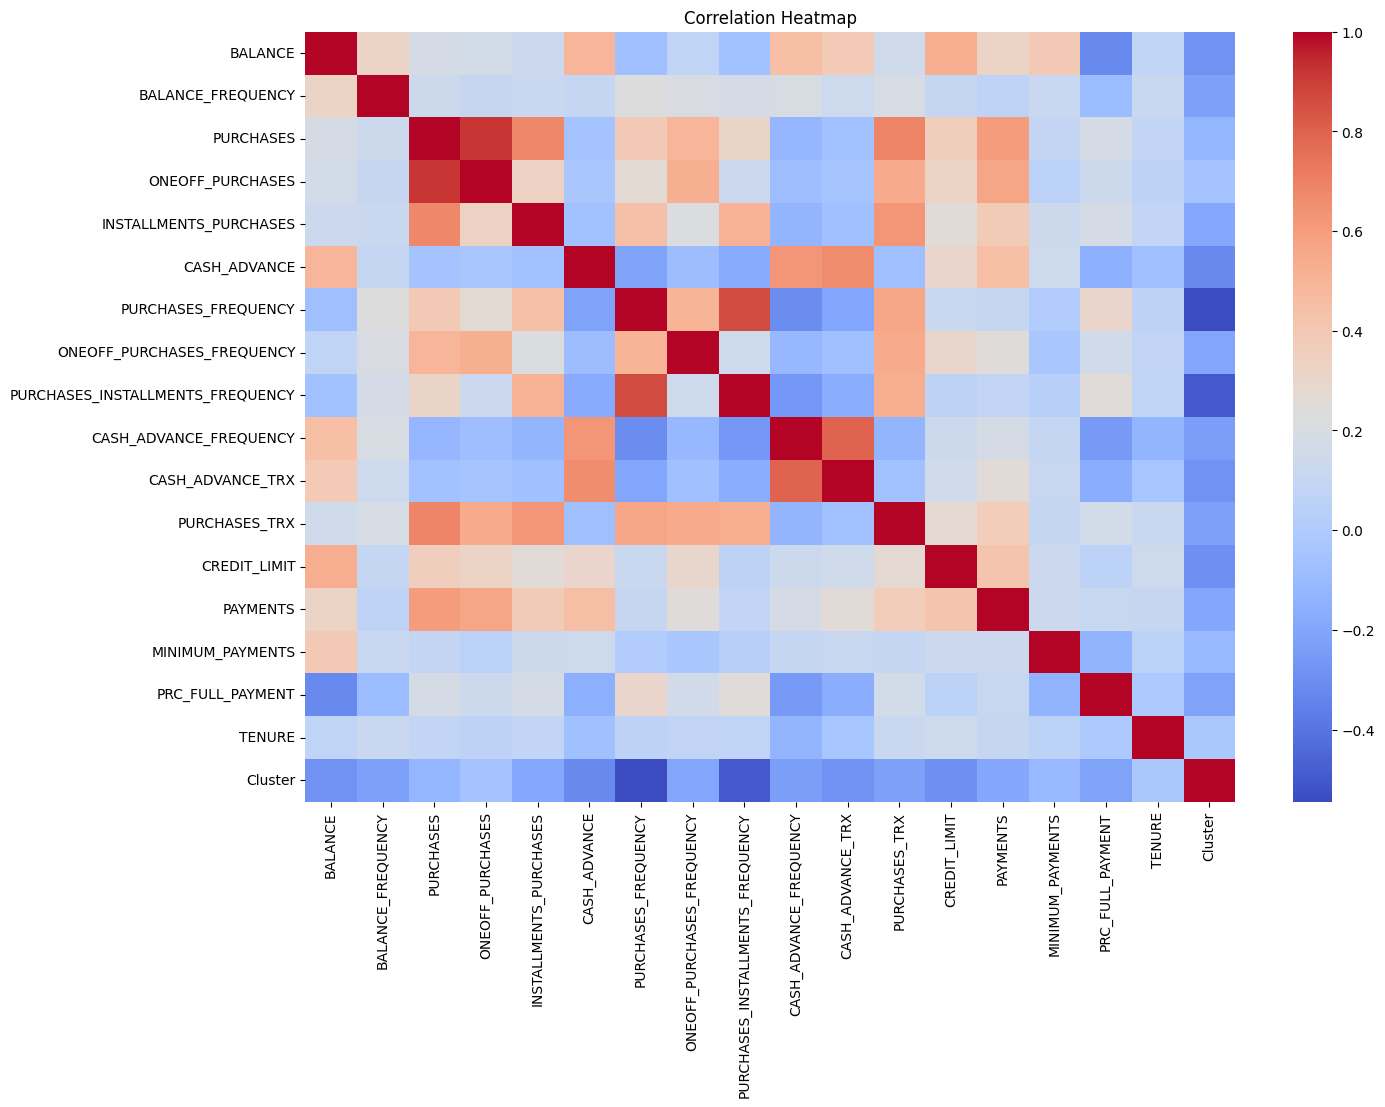

In [83]:
plt.figure(figsize=(15,10))

sns.heatmap(df.corr(), cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

In [84]:
kmeans = KMeans(n_clusters=4, random_state=42)

kmeans.fit(scaled_data)

KMeans(n_clusters=4, random_state=42)

In [85]:
clusters = kmeans.predict(scaled_data)

In [86]:
df['Cluster'] = clusters

In [87]:
from sklearn.metrics import davies_bouldin_score

dbi = davies_bouldin_score(scaled_data, clusters)

print("Davies-Bouldin Index:", dbi)

Davies-Bouldin Index: 1.438206335273125


# Conclusion

Berdasarkan hasil clustering menggunakan algoritma K-Means dengan 4 cluster, pelanggan berhasil dikelompokkan berdasarkan perilaku penggunaan kartu kredit.

Hasil evaluasi menunjukkan Silhouette Score sebesar 0.248 dan Davies-Bouldin Index sebesar 1.438, yang menunjukkan kualitas cluster cukup baik.

Visualisasi PCA memperlihatkan bahwa cluster dapat dipisahkan dengan cukup jelas dan masing-masing cluster memiliki karakteristik pelanggan yang berbeda.